#  Manipulação de Dados com Pandas: Análise Planilha de Futebol
Este notebook registra o aprendizado de fundamentos da biblioteca **Pandas**
---

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
df = pd.read_excel(r'D:/Area de trabalho/Data-Science-Learning/02-Python/Base-de-dados/campeonato_futebol.xlsx')
df.shape

(5, 10)

In [4]:
df.dtypes

Unnamed: 0          int64
Times                 str
Partidas_Jogadas    int64
Vitorias            int64
Empates             int64
Derrotas            int64
Gols_Pro            int64
Gols_Contra         int64
Saldo_Gols          int64
Pontos              int64
dtype: object

In [6]:
df.describe()    

,Unnamed: 0,Partidas_Jogadas,Vitorias,Empates,Derrotas,Gols_Pro,Gols_Contra,Saldo_Gols,Pontos
count,5.000000,5.0,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,2.000000,10.0,5.000000,6.200000,3.800000,16.000000,14.600000,1.400000,21.200000
std,1.581139,0.0,1.581139,8.871302,2.774887,4.472136,3.847077,8.294577,6.180615
min,0.000000,10.0,3.000000,1.000000,1.000000,10.000000,10.000000,-10.000000,15.000000
25%,1.000000,10.0,4.000000,2.000000,2.000000,14.000000,12.000000,-2.000000,18.000000
50%,2.000000,10.0,5.000000,3.000000,3.000000,16.000000,15.000000,1.000000,19.000000
75%,3.000000,10.0,6.000000,3.000000,5.000000,18.000000,16.000000,6.000000,23.000000
max,4.000000,10.0,7.000000,22.000000,8.000000,22.000000,20.000000,12.000000,31.000000


In [11]:
df.head(3)

,Unnamed: 0,Times,Partidas_Jogadas,Vitorias,Empates,Derrotas,Gols_Pro,Gols_Contra,Saldo_Gols,Pontos
0,4,Vasco,10,3,22,8,10,20,-10,31
1,0,Corinthians,10,7,2,1,22,10,12,23
2,2,Grêmio,10,6,1,3,16,15,1,19


In [12]:
df.tail(3)

,Unnamed: 0,Times,Partidas_Jogadas,Vitorias,Empates,Derrotas,Gols_Pro,Gols_Contra,Saldo_Gols,Pontos
2,2,Grêmio,10,6,1,3,16,15,1,19
3,1,Palmeiras,10,5,3,2,18,12,6,18
4,3,São Paulo,10,4,3,5,14,16,-2,15


In [23]:
# Análise de desempenho por time
desempenho_info = df[['Times','Pontos', 'Vitorias',  'Saldo_Gols']].set_index('Times')
desempenho_info

,Pontos,Vitorias,Saldo_Gols
Times,,,
Vasco,31,3,-10
Corinthians,23,7,12
Grêmio,19,6,1
Palmeiras,18,5,6
São Paulo,15,4,-2


In [ ]:
# Time com mais vitórias e

time_mais_vitoria = df[df['Vitorias'] == df['Vitorias'].max()]['Times'].values[0]
time_mais_vitoria

'Corinthians'

In [26]:
# Time com  menos vitórias

time_mais_vitoria = df[df['Vitorias'] == df['Vitorias'].min()]['Times'].values[0]
time_mais_vitoria

'Vasco'

In [36]:
# Distribuição de Gols Pro
df['Gols_Pro'].value_counts()

Gols_Pro
10    1
22    1
16    1
18    1
14    1
Name: count, dtype: int64

In [37]:
# Relação entre Gols pró e contras
correlacao = df['Gols_Pro'].corr(df['Pontos'])
correlacao

np.float64(-0.3798766677785213)

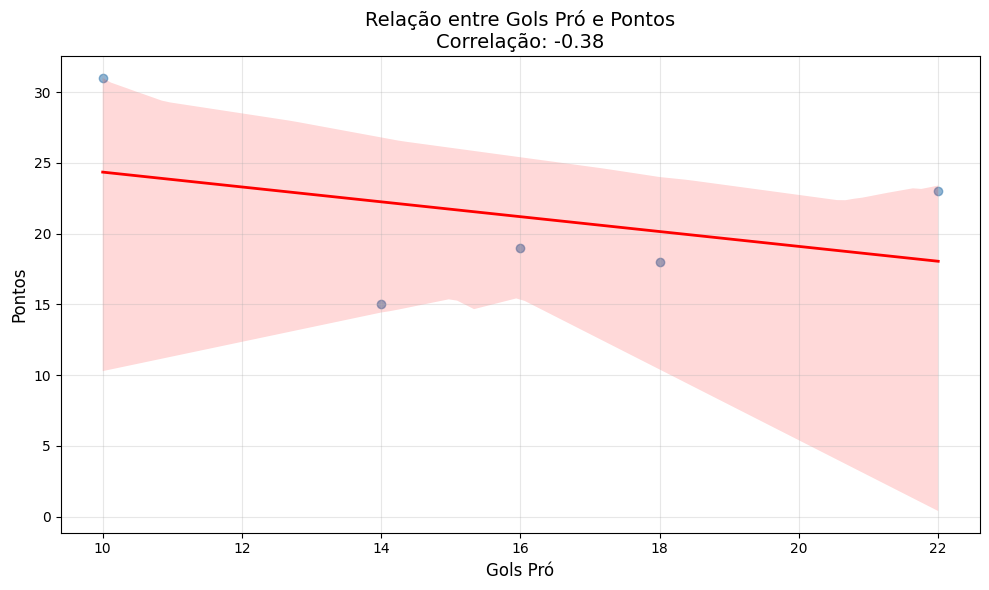

In [43]:
# Gráfico de dispersão com linha de tendência
plt.figure(figsize=(10, 6))
sns.regplot(x='Gols_Pro', y='Pontos', data=df, 
            scatter_kws={'alpha': 0.6, 'color': 'steelblue'},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title(f'Relação entre Gols Pró e Pontos\nCorrelação: {correlacao:.2f}', fontsize=14)
plt.xlabel('Gols Pró', fontsize=12)
plt.ylabel('Pontos', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()